In [1]:
# read data yearky in pickle file
import pickle
import sys
import os
import numpy as np
maindir = os.getcwd()
sys.path.append(maindir+"/src")


# data = pickle.load('data_yearly.pickle')

with open('data_yearly.pickle', 'rb') as f:
    data = pickle.load(f)

In [2]:
data_anomaly_yearly = data['dic_data_yearly']
data_forced_response_yearly = data['dic_forced_response_yearly']

In [3]:
# ### Training dates 
# years_train = np.arange(2100 - 1880 +1)

# # year index to a scalar in [0,1]
# years_train_idx_feature = years_train / (2100 - 1880)  # normalize to [0,1] range

# # get index of years 1950 - 2022
# years_test = years_train[(years_train >= 1950-1880) & (years_train <= 2022-1880)]
# years_test_idx_feature =  years_test/ (2100 - 1880)


# print("Training years:", years_train_idx_feature)
# print("Test years:", years_test_idx_feature)

In [4]:
import torch

def merge_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    
    for idx_m,m in enumerate(x.keys()):
        
        if idx_m ==0:

            x_train = x[m]/torch.sqrt(torch.tensor(x[m].shape[0]))
            y_train = y[m]/torch.sqrt(torch.tensor(x[m].shape[0]))


        else:
            x_train = torch.cat([x_train, x[m].to(torch.float32) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)
            y_train = torch.cat([y_train, y[m].to(torch.float32) /torch.sqrt(torch.tensor(x[m].shape[0]))],dim=0)

        print(f'  x_train shape: {x_train.shape}')
    return x_train, y_train


def reshape_training_data(x,y,dtype=torch.float32):
    """Concatenate training sets for all models except model m. This enables to create the big matrices X and Y.
        Unnormalized data.
       Args:

       Return:
    """
    ################ We construct X, Y in R^{grid x runs*time steps}

    # Concatenate all models to build the matrix X
    x_train = {}
    y_train = {}
    
    for idx_m,m in enumerate(x.keys()):
        
        x_train[m] = x[m].reshape(x[m].shape[0],x[m].shape[1],x[m].shape[2]*x[m].shape[3])
        y_train[m] = y[m].reshape(x[m].shape[0],x[m].shape[1],x[m].shape[2]*x[m].shape[3])
        print(f'  x_train shape: {x_train[m].shape}')
        print(f'  y_train shape: {y_train[m].shape}')
    return x_train, y_train

In [5]:
x_train_yearly, y_train_yearly  = merge_training_data(data_anomaly_yearly,data_forced_response_yearly,dtype=torch.float32)

x_train_yearly = x_train_yearly.view(-1,x_train_yearly.shape[2])
y_train_yearly = y_train_yearly.view(-1,y_train_yearly.shape[2])

  x_train shape: torch.Size([50, 221, 10368])
  x_train shape: torch.Size([75, 221, 10368])
  x_train shape: torch.Size([105, 221, 10368])
  x_train shape: torch.Size([155, 221, 10368])
  x_train shape: torch.Size([185, 221, 10368])


# Get Test data

In [6]:
import netCDF4 as netcdf

# read the test data
PATH_EVAL = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/Evaluation-Tier1/'


DIR_LIST_TEST = os.listdir(PATH_EVAL)
data_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

lst_test_name = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_') and file.endswith('.nc'):
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_EVAL, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[9] in lst_test_name:
            # find position of file[9] in lst_test_name
            idx_test = lst_test_name.index(file[9])
            print(f'  Found test data for {file[9]} at index {idx_test}')
            data_test[idx_test,:,:,:] = np.array(netcdf_file.variables['tas']) 
        
            for i in range(12):
                data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_test[idx_test,:,:,:].shape}')

  Processing 6/81: tas_mon_1F.195001-202212.nc
  Found test data for F at index 5


  Tas shape: (876, 72, 144)
  Processing 12/81: tas_mon_1C.195001-202212.nc
  Found test data for C at index 2
  Tas shape: (876, 72, 144)
  Processing 16/81: tas_mon_1H.195001-202212.nc
  Found test data for H at index 7
  Tas shape: (876, 72, 144)
  Processing 26/81: tas_mon_1G.195001-202212.nc
  Found test data for G at index 6
  Tas shape: (876, 72, 144)
  Processing 40/81: tas_mon_1D.195001-202212.nc
  Found test data for D at index 3
  Tas shape: (876, 72, 144)
  Processing 52/81: tas_mon_1J.195001-202212.nc
  Found test data for J at index 9
  Tas shape: (876, 72, 144)
  Processing 58/81: tas_mon_1A.195001-202212.nc
  Found test data for A at index 0
  Tas shape: (876, 72, 144)
  Processing 60/81: tas_mon_1E.195001-202212.nc
  Found test data for E at index 4
  Tas shape: (876, 72, 144)
  Processing 71/81: tas_mon_1B.195001-202212.nc
  Found test data for B at index 1
  Tas shape: (876, 72, 144)
  Processing 77/81: tas_mon_1I.195001-202212.nc
  Found test data for I at index 8
 

In [7]:
# Read the ground truth data

PATH_GROUND_TRUTH = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ensmeans-Tier1'

DIR_LIST_GROUND_TRUTH = os.listdir(PATH_GROUND_TRUTH)

data_ground_truth_test = np.zeros((10, 876, 72, 144), dtype=np.float32)

for idx_r, file in enumerate(DIR_LIST_GROUND_TRUTH):

    if file.__contains__('.tas.'):
        
        print(f'  Processing {idx_r+1}: {file}')

        # read the ground truth data
        file_path = os.path.join(PATH_GROUND_TRUTH, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')

        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[1] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[1])
            print(f'  Found test data for {file[1]} at index {idx_test}')
            data_ground_truth_test[idx_test,:,:,:] = np.array(netcdf_file.variables['arr_EM'])

            for i in range(12):
                data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] = data_ground_truth_test[idx_test,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_ground_truth_test[idx_test, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)

            print(f'  Tas shape: {data_ground_truth_test[idx_test,:,:,:].shape}')

  Processing 7: 1A.tas.EM.1950-2022.nc
  Found test data for A at index 0
  Tas shape: (876, 72, 144)
  Processing 15: 1B.tas.EM.1950-2022.nc
  Found test data for B at index 1
  Tas shape: (876, 72, 144)
  Processing 23: 1C.tas.EM.1950-2022.nc
  Found test data for C at index 2
  Tas shape: (876, 72, 144)
  Processing 31: 1D.tas.EM.1950-2022.nc
  Found test data for D at index 3
  Tas shape: (876, 72, 144)
  Processing 39: 1E.tas.EM.1950-2022.nc
  Found test data for E at index 4
  Tas shape: (876, 72, 144)
  Processing 47: 1F.tas.EM.1950-2022.nc
  Found test data for F at index 5
  Tas shape: (876, 72, 144)
  Processing 55: 1G.tas.EM.1950-2022.nc
  Found test data for G at index 6
  Tas shape: (876, 72, 144)
  Processing 63: 1H.tas.EM.1950-2022.nc
  Found test data for H at index 7
  Tas shape: (876, 72, 144)
  Processing 71: 1J.tas.EM.1950-2022.nc
  Found test data for J at index 9
  Tas shape: (876, 72, 144)


In [8]:
# Read the estimates of the other methods
# read the test data
PATH_TEST = '/net/krypton/climdyn_nobackup/FTP/ForceSMIP_Tier1_final/ForceSMIP-estimates-Tier1'

DIR_LIST_TEST = os.listdir(PATH_TEST)
data_estimates = np.zeros((30,10, 876, 72, 144), dtype=np.float32)


for idx_r, file in enumerate(DIR_LIST_TEST):

    if file.startswith('tas_'):

        # read the test data
        print(f'  Processing {idx_r+1}/{len(DIR_LIST_TEST)}: {file}')
        file_path = os.path.join(PATH_TEST, file)
        netcdf_file = netcdf.Dataset(file_path, 'r')


        # set variables
        time = np.array(netcdf_file.variables['time'])
        longitude = np.array(netcdf_file.variables['lon'])
        latitude = np.array(netcdf_file.variables['lat'])

        if file[5] in lst_test_name:
            # find position of file[1] in lst_test_name
            idx_test = lst_test_name.index(file[5])
            print(f'  Found test data for {file[5]} at index {idx_test}')
            data_estimates[:,idx_test,:,:,:] = np.array(netcdf_file.variables['forced_component']) 

        print(f'  Tas shape: {data_estimates[:,idx_test,:,:,:].shape}')

lst_to_center = [8,9,14,24]

# center the methods that are not centered
for idx_m in lst_to_center:
    print(f'Centering data for method {idx_m}')
    for i in range(12):
        data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] = data_estimates[idx_m,:,np.arange(time.shape[0]) % 12 == i,:,:] - np.nanmean(data_estimates[idx_m,:, np.arange(time.shape[0]) % 12 == i ,:,:], axis=0)




  Processing 51/80: tas_1A_1950_2022.nc
  Found test data for A at index 0
  Tas shape: (30, 876, 72, 144)
  Processing 52/80: tas_1B_1950_2022.nc
  Found test data for B at index 1
  Tas shape: (30, 876, 72, 144)
  Processing 53/80: tas_1C_1950_2022.nc
  Found test data for C at index 2
  Tas shape: (30, 876, 72, 144)
  Processing 54/80: tas_1D_1950_2022.nc
  Found test data for D at index 3
  Tas shape: (30, 876, 72, 144)
  Processing 55/80: tas_1E_1950_2022.nc
  Found test data for E at index 4
  Tas shape: (30, 876, 72, 144)
  Processing 56/80: tas_1F_1950_2022.nc
  Found test data for F at index 5
  Tas shape: (30, 876, 72, 144)
  Processing 57/80: tas_1G_1950_2022.nc
  Found test data for G at index 6
  Tas shape: (30, 876, 72, 144)
  Processing 58/80: tas_1H_1950_2022.nc
  Found test data for H at index 7
  Tas shape: (30, 876, 72, 144)
  Processing 59/80: tas_1I_1950_2022.nc
  Found test data for I at index 8
  Tas shape: (30, 876, 72, 144)
  Processing 60/80: tas_1J_1950_2022.

In [9]:
def yearly_average(x, months_per_year=12):
    """
    Compute the yearly average of a time series.
    Args:
        data: numpy array of shape (time, ...)
        months_per_year: int, number of months in a year (default: 12)
    Returns:
        numpy array of shape (years, ...)
    """
    n_years = x.shape[1] // months_per_year
    data_reshaped = x.reshape(x.shape[0],n_years, months_per_year, x.shape[2],x.shape[3])
    return data_reshaped.mean(axis=2)

In [10]:
# Compute yearly averages for the test data
x_test_yearly = yearly_average(data_test, months_per_year=12)
y_test_yearly = yearly_average(data_ground_truth_test, months_per_year=12)

# transform to pytorch tensors and reshape
x_test_yearly = torch.from_numpy(x_test_yearly).to(torch.float32).reshape(x_test_yearly.shape[0],x_test_yearly.shape[1],x_test_yearly.shape[2]*x_test_yearly.shape[3])
y_test_yearly = torch.from_numpy(y_test_yearly).to(torch.float32).reshape(y_test_yearly.shape[0],y_test_yearly.shape[1],y_test_yearly.shape[2]*y_test_yearly.shape[3])

In [11]:
data_estimates_yearly = np.zeros((data_estimates.shape[0], data_estimates.shape[1], data_estimates.shape[2]//12, 72, 144), dtype=np.float32)
for idx_m in range(data_estimates.shape[0]):
    data_estimates_yearly[idx_m,:,:,:,:] = yearly_average(data_estimates[idx_m,:,:,:], months_per_year=12)


# compute mse of the other estimates
mse_estimates = np.zeros((data_estimates.shape[0],data_estimates.shape[1]))

for idx_r in range(data_estimates.shape[0]):
    mse_estimates[idx_r,:] = np.sqrt(np.mean((data_estimates[idx_r,:,:,:,:] - data_ground_truth_test) ** 2,axis=(1,2,3))) 
    print(f'  MSE estimates: {mse_estimates[idx_r,:]}')

mse_estimates[:,8] = 0.0

  MSE estimates: [0.49550778 0.51100057 0.67596477 0.84101903 0.48415652 0.47930476
 0.61143172 0.43098748 0.64807928 0.51178229]
  MSE estimates: [0.51639372 0.5460459  0.65299219 0.7674492  0.49941075 0.50957346
 0.57887173 0.46936822 0.68619871 0.59348494]
  MSE estimates: [0.49182796 0.5012449  0.58460832 0.87728935 0.48170397 0.48428568
 0.55289179 0.44784209 0.7546466  0.57025641]
  MSE estimates: [0.43085137 0.56283027 0.78117096 0.44237232 0.5036909  0.4146412
 0.49771696 0.31438255 0.44269887 0.48009971]
  MSE estimates: [0.42836311 0.43215752 0.62536472 0.59834325 0.44574437 0.43019038
 0.52151704 0.38851166 0.53218716 0.47624314]
  MSE estimates: [0.36044395 0.38175088 0.56761026 0.45852318 0.4024646  0.35533607
 0.47676918 0.31087133 0.44567934 0.43520856]
  MSE estimates: [0.38899282 0.41481045 0.6190955  0.73331398 0.422548   0.38153708
 0.50368208 0.33451095 0.55205292 0.43823734]
  MSE estimates: [0.49169007 0.50437868 0.69514912 0.77526796 0.50779128 0.50623846
 0.5940

# Build the classifier for the training set

In [12]:
### Training dates 
years_train = np.arange(2100 - 1880 +1)

# year index to a scalar in [0,1]
years_train_idx_feature = years_train # normalize to [0,1] range

# get index of years 1950 - 2022
years_test = years_train[(years_train >= 1950-1880) & (years_train <= 2022-1880)]
years_test_idx_feature =  years_test


print("Training years:", years_train_idx_feature)
print("Test years:", years_test_idx_feature)

Training years: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220]
Test years: [ 70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87
 

In [13]:
# models = list(data_anomaly_yearly.keys())

# x_stacked, y_stacked = stack_models_and_runs(models,data_anomaly_yearly, data_forced_response_yearly)

In [14]:
# predicted_labels = model.predict(x_test_yearly.detach().numpy().reshape(x_test_yearly.shape[0], -1 ))  # reshape to (n_samples, n_features)
# predicted_proba = model.predict_proba(x_test_yearly.detach().numpy().reshape(x_test_yearly.shape[0], -1 ))  # reshape to (n_samples, n_features)

In [15]:
# predicted_training_labels = model.predict(x_train_classifier.reshape(x_train_classifier.shape[0], -1 ))  # reshape to (n_samples, n_features)

In [16]:
# # plot histogram of predicted labels
# import matplotlib.pyplot as plt
# plt.hist(predicted_labels, bins=np.arange(num_classes+1)-0.5, density=True, alpha=0.7, label='Predicted Labels')
# plt.hist(labels, bins=np.arange(num_classes+1)-0.5, density=True, alpha=0.7, label='True Labels')
# plt.xlabel('Classes')
# plt.ylabel('Density')
# plt.title('Histogram of Predicted and True Labels')
# plt.legend()
# plt.show()

# Train and test our classifier

In [17]:
from preprocessing import stack_models_and_runs

# test the classifier on the training data
# remove some samples from the training set
#train on the 3/4 of the training data for each model

data_anomaly_yearly_train = {}
data_anomaly_yearly_test = {}

data_forced_response_yearly_train = {}
data_forced_response_yearly_test = {}

for m in data_anomaly_yearly.keys():
    nb_samples = int(data_anomaly_yearly[m].shape[0] * 0.5)
    data_anomaly_yearly_train[m] = data_anomaly_yearly[m][:nb_samples,years_test_idx_feature,:]
    data_anomaly_yearly_test[m] = data_anomaly_yearly[m][nb_samples:,years_test_idx_feature,:]

    data_forced_response_yearly_train[m] = data_forced_response_yearly[m][:nb_samples,years_test_idx_feature,:]
    data_forced_response_yearly_test[m] = data_forced_response_yearly[m][nb_samples:,years_test_idx_feature,:]

# create the stacked training data
x_train, y_train  = merge_training_data(data_anomaly_yearly_train,data_forced_response_yearly_train,dtype=torch.float32)
x_train = x_train.view(x_train.shape[0],-1)
y_train = y_train.view(y_train.shape[0],-1)


# create the stacked test data
x_test, y_test  = merge_training_data(data_anomaly_yearly_test,data_forced_response_yearly_test,dtype=torch.float32)
x_test = x_test.view(x_test.shape[0],-1)
y_test = y_test.view(y_test.shape[0],-1)

  x_train shape: torch.Size([25, 73, 10368])
  x_train shape: torch.Size([37, 73, 10368])
  x_train shape: torch.Size([52, 73, 10368])
  x_train shape: torch.Size([77, 73, 10368])
  x_train shape: torch.Size([92, 73, 10368])
  x_train shape: torch.Size([25, 73, 10368])
  x_train shape: torch.Size([38, 73, 10368])
  x_train shape: torch.Size([53, 73, 10368])
  x_train shape: torch.Size([78, 73, 10368])
  x_train shape: torch.Size([93, 73, 10368])


In [18]:
models = list(data_anomaly_yearly_train.keys())

# build the dataset for training the classifier
x_stacked, y_stacked = stack_models_and_runs(models,data_anomaly_yearly_train, data_forced_response_yearly_train)   

# define labels for each sample
labels = np.zeros((x_stacked.shape[0]), dtype=np.int64)
last_idx = 0

# Assign labels based on the model index
for idx_m, m in enumerate(list(data_anomaly_yearly_train.keys())):
    # Get the indices for the current model

    labels[last_idx:last_idx+data_anomaly_yearly_train[m].shape[0]] = idx_m
    last_idx = last_idx+data_anomaly_yearly_train[m].shape[0]

time_length = len(years_test_idx_feature)

x_train_classifier = np.zeros((x_stacked.shape[0], time_length * x_stacked.shape[2]), dtype=np.float32)
last_idx = 0
for idx_m, m in enumerate(list(data_anomaly_yearly_train.keys())):
    x_train_classifier[last_idx:last_idx+data_anomaly_yearly_train[m].shape[0],:] = x_stacked[last_idx:last_idx+data_anomaly_yearly_train[m].shape[0],:,:].reshape(data_anomaly_yearly_train[m].shape[0], -1)
    last_idx = last_idx + data_anomaly_yearly_train[m].shape[0]

In [19]:
# build the labels for the test data
labels_test = np.zeros((x_test.shape[0]), dtype=np.int64)
last_idx = 0

# Assign labels based on the model index
for idx_m, m in enumerate(list(data_anomaly_yearly_test.keys())):
    
    # Get the indices for the current model
    labels_test[last_idx:last_idx+data_anomaly_yearly_test[m].shape[0]] = idx_m
    last_idx = last_idx+data_anomaly_yearly_test[m].shape[0]

In [20]:
from sklearn.linear_model import LogisticRegression

# train the classifier
num_classes = len(data_anomaly_yearly_train.keys())
num_features = time_length * x_stacked.shape[2]
model = LogisticRegression(penalty='l2', C=100.0)


model.fit(x_train_classifier, labels)

LogisticRegression(C=100.0)

In [21]:
# test on the test data
predicted_labels_test = model.predict(x_test.detach().numpy().reshape(x_test.shape[0], -1 ))  # reshape to (n_samples, n_features)
predicted_proba_test = model.predict_proba(x_test.detach().numpy().reshape(x_test.shape[0], -1 ))  # reshape to (n_samples, n_features)

# Train the classifier on all training data

In [22]:
# train a classifier
from sklearn.linear_model import LogisticRegression

x_stacked, y_stacked = stack_models_and_runs(models,data_anomaly_yearly, data_forced_response_yearly)

# define labels for each sample
labels = np.zeros((x_stacked.shape[0]), dtype=np.int64)
last_idx = 0

# Assign labels based on the model index
for idx_m, m in enumerate(list(data_anomaly_yearly.keys())):
    # Get the indices for the current model

    labels[last_idx:last_idx+data_anomaly_yearly[m].shape[0]] = idx_m
    last_idx = last_idx+data_anomaly_yearly[m].shape[0]

time_length = len(years_test_idx_feature)

x_train_classifier = np.zeros((x_stacked.shape[0], time_length * x_stacked.shape[2]), dtype=np.float32)
last_idx = 0
for idx_m, m in enumerate(list(data_anomaly_yearly.keys())):
    x_train_classifier[last_idx:last_idx+data_anomaly_yearly[m].shape[0],:] = x_stacked[last_idx:last_idx+data_anomaly_yearly[m].shape[0],years_test_idx_feature,:].reshape(data_anomaly_yearly[m].shape[0], -1)
    last_idx = last_idx + data_anomaly_yearly[m].shape[0]

In [23]:
# train the classifier
num_classes = len(data_anomaly_yearly.keys())
num_features = time_length * x_stacked.shape[2]
model = LogisticRegression(penalty='l2', C=1.0)


model.fit(x_train_classifier, labels)

LogisticRegression()

In [24]:
# compute probabilities of the test data
predicted_labels = model.predict(x_test_yearly.detach().numpy().reshape(x_test_yearly.shape[0], -1 ))  # reshape to (n_samples, n_features)
predicted_proba = model.predict_proba(x_test_yearly.detach().numpy().reshape(x_test_yearly.shape[0], -1 ))    

# Train the ridge regression 

In [ ]:
from algorithms import ridge_regression, ridge_regression_low_rank

# penalty parameters
lambda_tmp = 1000.0

# ridge regression
w_ridge = ridge_regression(x_train_yearly, y_train_yearly, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

# low rank regression
U,S,V = torch.linalg.svd(x_train_yearly@w_ridge,full_matrices=False)

Loss function:  1266297.875


In [60]:
# define the rank
rank = 5

w_ridge_low_rank = w_ridge @ V[:rank,:].T @ V[:rank,:]

In [61]:
# Evaluate the model on test data
y_pred = x_test_yearly @ w_ridge
y_pred_low_rank = x_test_yearly @ w_ridge_low_rank


# Compute the mean squared error
rmse = torch.sqrt(torch.mean((y_pred - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank = torch.sqrt(torch.mean((y_pred_low_rank - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

print(f'  MSE: {rmse}')
print(f'  MSE low-rank: {rmse_low_rank}')

  MSE: [0.38542634 0.47753766 0.74637544 0.4534409  0.52475065 0.45836684
 0.5320085  0.38270858 0.07508434 0.4398615 ]
  MSE low-rank: [0.3871454  0.4782938  0.74899215 0.45569408 0.52596456 0.46094373
 0.5323615  0.38458714 0.07371357 0.4402444 ]


In [28]:
# Train the robust model with autograd
def robust_ridge_regression(x, y, d, lambda_=1.0, mu_=1.0, verbose=False, dtype=torch.float32):
    """
    Robust ridge regression with low-rank approximation.
    
    Args:
        x: input data (torch.Tensor)
        y: target data (torch.Tensor)
        lambda_: regularization parameter (float)
        rank: rank for low-rank approximation (int)
        verbose: if True, print additional information (bool)
        dtype: data type for the tensors (torch.dtype)
        
    Returns:
        w: weights of the model (torch.Tensor)
    """
    w = torch.zeros((d, d), dtype=dtype).requires_grad_(True)

    optimizer = torch.optim.Adam([w], lr=1e-3)

    loss_tmp = torch.zeros(len(x.keys()), dtype=dtype)

    for epoch in range(10):
        optimizer.zero_grad()
        
        for idx_m,m in enumerate(list(x.keys())):
            x_m = x[m].to(dtype)
            y_m = y[m].to(dtype)

            # Compute the prediction
            y_pred = x_m @ w
            
            # Compute the loss
            loss_tmp[idx_m] = (1/mu_)*torch.nanmean((y_pred - y_m) ** 2)


        loss = mu_*torch.logsumexp(loss_tmp, dim=0) + lambda_ * torch.norm(w, p='fro')**2

        # Backpropagation
        loss.backward(retain_graph=True)
        
        # Update weights
        optimizer.step()

        print(f'Epoch {epoch}, Loss: {loss.item()}')
        
        # if verbose and epoch % 100 == 0:
        #     print(f'Epoch {epoch}, Loss: {loss.item()}')            

    if verbose:
        print(f'  Weights shape: {w.shape}')
    
    return w

In [29]:
# d = longitude.shape[0] * latitude.shape[0]  # Assuming longitude is a 2D grid, flatten it to a 1D vector
# w = robust_ridge_regression(data_anomaly_yearly, data_forced_response_yearly, d, lambda_=100.0, mu_=1.0, verbose=False, dtype=torch.float32)

In [30]:
# # Evaluate the model on test data
# y_pred_robust = x_test_yearly @ w

# # Compute the mean squared error
# rmse_linreg = torch.sqrt(torch.mean((y_pred_robust - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

# print(f'  MSE: {rmse_linreg}')

# Idea 1: Linear regression per grid cell

In [31]:
def linear_regression_per_grid_cell(x,y,lambda_=0.0):
    """Perform linear regression for each grid cell and return the coefficients.
       Args:
           x: numpy array of shape (runs, time steps, latitude x longitude)
           y: numpy array of shape (runs, time steps, latitude x longitude)
       Return:
           w: numpy array of shape (latitude x longitude, runs*time steps)
    """

    # Compute the coefficients for each grid cell
    # w = np.linalg.lstsq(x, y, rcond=None)[0]
    w = torch.sum(x * y, axis=0) / (torch.sum(x ** 2, axis=0)+lambda_)
    
    return w

In [32]:
# linear regression per grid cell
w = linear_regression_per_grid_cell(x_train_yearly, y_train_yearly,lambda_=1.0)

# define the matrix W with diagonal matrix w
w_reg_lin = torch.diag_embed(w)

In [33]:
# Evaluate the model on test data
y_pred_linreg = x_test_yearly @ w_reg_lin

# Compute the mean squared error
rmse_linreg = torch.sqrt(torch.mean((y_pred_linreg - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

print(f'  MSE: {rmse}')
print(f'  MSE trace norm: {rmse_low_rank}')
print(f'  MSE linear regression: {rmse_linreg}')

  MSE: [0.17431763 0.20424017 0.25173718 0.40733692 0.20914215 0.1640997
 0.24260566 0.15507151 0.5075444  0.24035856]
  MSE trace norm: [0.17885357 0.2052549  0.26803577 0.41344923 0.22129339 0.1837789
 0.24196193 0.16467954 0.5043241  0.23973066]
  MSE linear regression: [0.6066988  0.59682083 0.6470432  0.82042867 0.5586161  0.57434744
 0.65690213 0.57404286 0.7560741  0.64246166]


# Idea 2: Smoothing of temporal time series

In [34]:
import torch.nn.functional as F

def moving_average_smoothing(x, window_size=5, mode='same'):
    """
    Apply moving average smoothing to multivariate time series using PyTorch.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
           where first dimension is number of samples, second is time, third is features
        window_size: int, size of the moving average window
        mode: str, padding mode - 'same' keeps original length, 'valid' reduces length
    
    Returns:
        smoothed_x: torch.Tensor of same shape as input (if mode='same') or reduced size
    """
    n_samples, n_timesteps, n_features = x.shape
    
    # Create uniform kernel for moving average
    kernel = torch.ones(1, 1, window_size, dtype=x.dtype, device=x.device) / window_size
    
    # Reshape input for conv1d: (batch_size * n_features, 1, n_timesteps)
    x_reshaped = x.permute(0, 2, 1).reshape(n_samples * n_features, 1, n_timesteps)
    
    # Apply padding if mode is 'same'
    if mode == 'same':
        padding = window_size // 2
        x_padded = F.pad(x_reshaped, (padding, padding), mode='reflect')
        smoothed = F.conv1d(x_padded, kernel)
        
        # Ensure output has the same length as input by trimming if necessary
        if smoothed.shape[-1] > n_timesteps:
            # Trim the extra timestep(s) from the end
            smoothed = smoothed[:, :, :n_timesteps]
        elif smoothed.shape[-1] < n_timesteps:
            # This shouldn't happen with proper padding, but handle it just in case
            padding_needed = n_timesteps - smoothed.shape[-1]
            smoothed = F.pad(smoothed, (0, padding_needed), mode='replicate')
            
    else:  # mode == 'valid'
        smoothed = F.conv1d(x_reshaped, kernel)
    
    # Reshape back to original format
    if mode == 'same':
        smoothed = smoothed.reshape(n_samples, n_features, n_timesteps).permute(0, 2, 1)
    else:
        new_timesteps = smoothed.shape[-1]
        smoothed = smoothed.reshape(n_samples, n_features, new_timesteps).permute(0, 2, 1)
    
    return smoothed

def exponential_smoothing(x, alpha=0.1):
    """
    Apply exponential smoothing to multivariate time series.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        alpha: float, smoothing parameter (0 < alpha <= 1)
    
    Returns:
        smoothed_x: torch.Tensor of same shape as input
    """
    smoothed = torch.zeros_like(x)
    smoothed[:, 0, :] = x[:, 0, :]  # Initialize with first timestep
    
    for t in range(1, x.shape[1]):
        smoothed[:, t, :] = alpha * x[:, t, :] + (1 - alpha) * smoothed[:, t-1, :]
    
    return smoothed

def gaussian_smoothing(x, window_size=5, sigma=1.0):
    """
    Apply Gaussian smoothing to multivariate time series.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        window_size: int, size of the Gaussian kernel (should be odd)
        sigma: float, standard deviation of Gaussian kernel
    
    Returns:
        smoothed_x: torch.Tensor of same shape as input
    """
    n_samples, n_timesteps, n_features = x.shape
    
    # Create Gaussian kernel
    kernel_range = torch.arange(window_size, dtype=x.dtype, device=x.device) - window_size // 2
    kernel = torch.exp(-0.5 * (kernel_range / sigma) ** 2)
    kernel = kernel / kernel.sum()  # Normalize
    kernel = kernel.view(1, 1, window_size)
    
    # Reshape input for conv1d
    x_reshaped = x.permute(0, 2, 1).reshape(n_samples * n_features, 1, n_timesteps)
    
    # Apply padding and convolution
    padding = window_size // 2
    x_padded = F.pad(x_reshaped, (padding, padding), mode='reflect')
    smoothed = F.conv1d(x_padded, kernel)
    
    # Ensure output has the same length as input by trimming if necessary
    if smoothed.shape[-1] > n_timesteps:
        # Trim the extra timestep(s) from the end
        smoothed = smoothed[:, :, :n_timesteps]
    elif smoothed.shape[-1] < n_timesteps:
        # This shouldn't happen with proper padding, but handle it just in case
        padding_needed = n_timesteps - smoothed.shape[-1]
        smoothed = F.pad(smoothed, (0, padding_needed), mode='replicate')
    
    # Reshape back
    smoothed = smoothed.reshape(n_samples, n_features, n_timesteps).permute(0, 2, 1)
    
    return smoothed

# Example usage with x_test_yearly
print(f"Original x_test_yearly shape: {x_test_yearly.shape}")

# Apply different smoothing methods
window_size = 15

# Moving average smoothing
x_test_ma = moving_average_smoothing(x_test_yearly, window_size=window_size, mode='same')
print(f"Moving average smoothed shape: {x_test_ma.shape}")

# Exponential smoothing
x_test_exp = exponential_smoothing(x_test_yearly, alpha=0.2)
print(f"Exponential smoothed shape: {x_test_exp.shape}")

# Gaussian smoothing
x_test_gauss = gaussian_smoothing(x_test_yearly, window_size=window_size, sigma=2.0)
print(f"Gaussian smoothed shape: {x_test_gauss.shape}")

# Compare RMSE with different smoothing methods
rmse_ma = torch.sqrt(torch.mean((x_test_ma - y_test_yearly) ** 2, axis=(1,2))).detach().numpy()
rmse_exp = torch.sqrt(torch.mean((x_test_exp - y_test_yearly) ** 2, axis=(1,2))).detach().numpy()
rmse_gauss = torch.sqrt(torch.mean((x_test_gauss - y_test_yearly) ** 2, axis=(1,2))).detach().numpy()

print(f"\nRMSE comparison:")
print(f"  Original (no smoothing): {rmse}")
print(f"  Moving average: {rmse_ma}")
print(f"  Exponential smoothing: {rmse_exp}")
print(f"  Gaussian smoothing: {rmse_gauss}")

Original x_test_yearly shape: torch.Size([10, 73, 10368])
Moving average smoothed shape: torch.Size([10, 73, 10368])
Exponential smoothed shape: torch.Size([10, 73, 10368])
Gaussian smoothed shape: torch.Size([10, 73, 10368])

RMSE comparison:
  Original (no smoothing): [0.17431763 0.20424017 0.25173718 0.40733692 0.20914215 0.1640997
 0.24260566 0.15507151 0.5075444  0.24035856]
  Moving average: [0.24866363 0.27606732 0.330323   0.688749   0.2391012  0.25234845
 0.2923895  0.22760332 0.58343554 0.28170142]
  Exponential smoothing: [0.32316542 0.364579   0.39509574 0.71219575 0.30638105 0.32693008
 0.38211337 0.30395192 0.59413433 0.34083724]
  Gaussian smoothing: [0.34253618 0.34593016 0.38338137 0.735725   0.29775515 0.32735857
 0.39475203 0.3088015  0.6286752  0.34302822]


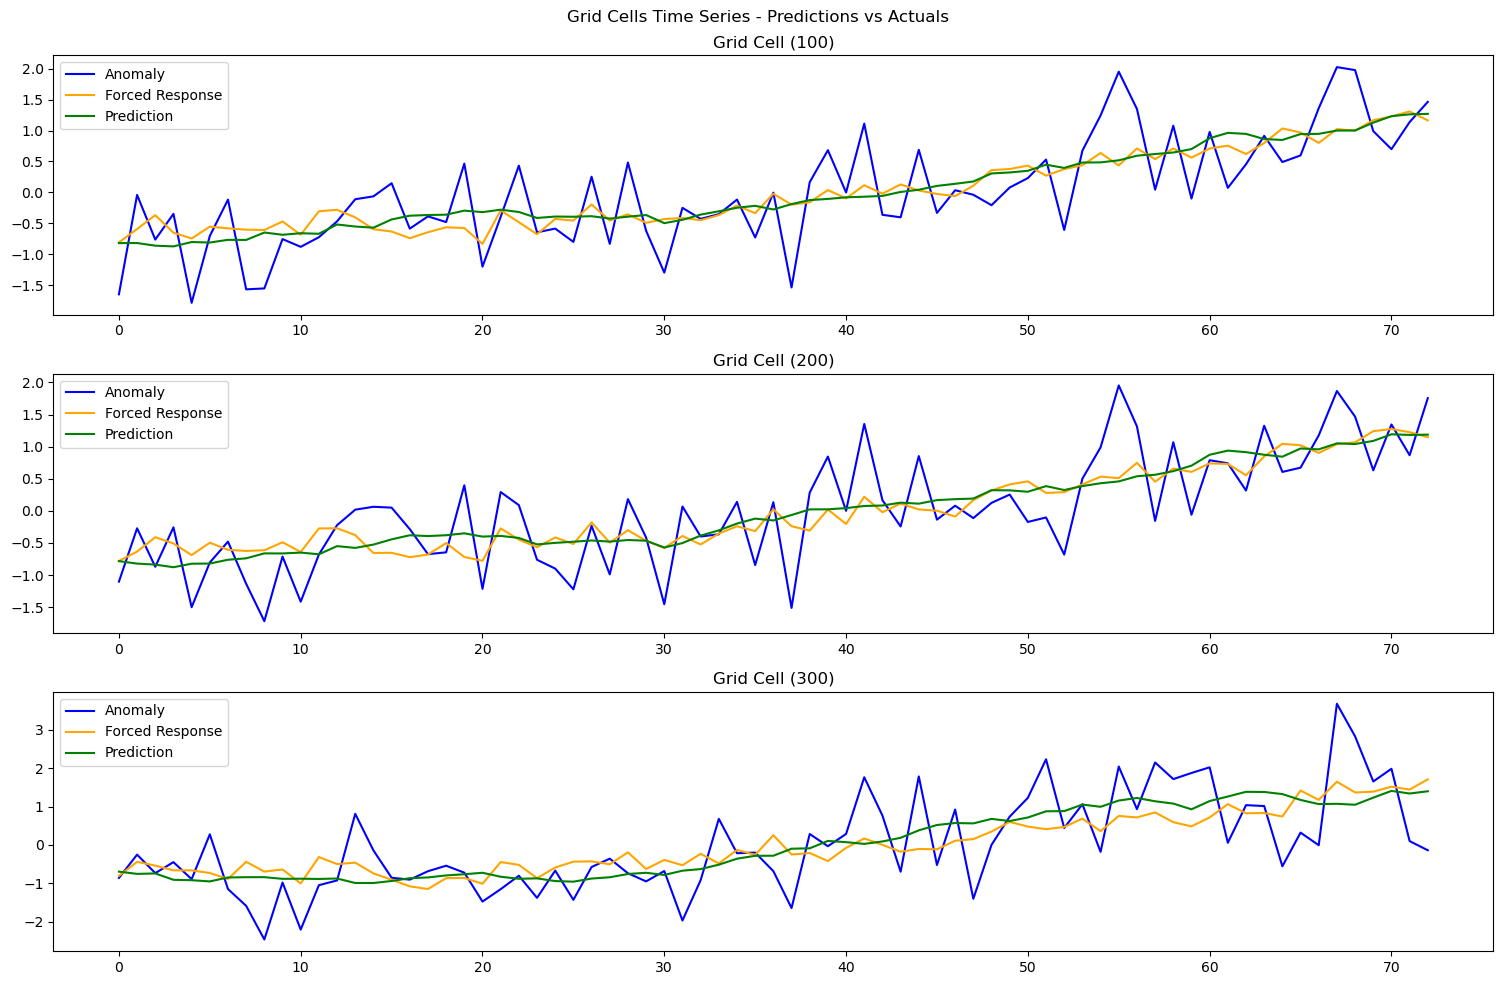

In [35]:
# plot some grid cells time series of the predictions, the input and the target forced response
import matplotlib.pyplot as plt

def plot_grid_cells_time_series(x, y, y_pred, grid_cells,idx_run, title='Grid Cells Time Series'):
    """
    Plot time series for specified grid cells.
    
    Args:
        x: Input data (anomaly)
        y: Target data (forced response)
        y_pred: Predicted data
        grid_cells: List of tuples (lat_idx, lon_idx) for grid cells to plot
        title: Title of the plot
    """
    plt.figure(figsize=(15, 10))
    
    for grid_idx in grid_cells:
        plt.subplot(len(grid_cells), 1, grid_cells.index(grid_idx) + 1)
        plt.plot(x[idx_run,:, grid_idx], label='Anomaly', color='blue')
        plt.plot(y[idx_run,:, grid_idx], label='Forced Response', color='orange')
        plt.plot(y_pred[idx_run,:, grid_idx], label='Prediction', color='green')
        plt.title(f'Grid Cell ({grid_idx})')
        plt.legend()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Example grid cells to plot (latitude index, longitude index)
grid_cells_to_plot = [100,200,300]  # Adjust indices based on your data shape
idx_run = 2
plot_grid_cells_time_series(x_test_yearly, y_test_yearly, x_test_ma, grid_cells_to_plot, idx_run, title='Grid Cells Time Series - Predictions vs Actuals')


In [36]:
# Evaluate the model on the smoothed data
y_pred_ma = x_test_ma @ w_ridge
y_pred_low_rank_ma = x_test_ma @ w_ridge_low_rank


# Compute the mean squared error
rmse_ma = torch.sqrt(torch.mean((y_pred_ma - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_ma = torch.sqrt(torch.mean((y_pred_low_rank_ma - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

print(f'  MSE: {rmse}')
print(f'  MSE trace norm: {rmse_low_rank}')

print(f'  MSE ma: {rmse_ma}')
print(f'  MSE trace norm ma: {rmse_low_rank_ma}')

  MSE: [0.17431763 0.20424017 0.25173718 0.40733692 0.20914215 0.1640997
 0.24260566 0.15507151 0.5075444  0.24035856]
  MSE trace norm: [0.17885357 0.2052549  0.26803577 0.41344923 0.22129339 0.1837789
 0.24196193 0.16467954 0.5043241  0.23973066]
  MSE ma: [0.15476349 0.17823629 0.26259172 0.3872918  0.20565344 0.14791733
 0.20561989 0.1419748  0.47655427 0.22767374]
  MSE trace norm ma: [0.16149075 0.18434568 0.27808523 0.39495927 0.21843918 0.16972978
 0.20760818 0.15443276 0.47535816 0.22954819]


# Idea 3: Learn M denoising models and provide a combination of all predictions

In [37]:
# learn a ridge regression for each climate model

w_ridge_per_model = {}
w_ridge_low_rank_per_model = {}

rmse_per_model = {}
rmse_low_rank_per_model = {}

for dir in list(data_anomaly_yearly.keys()):
    print(f'Computing ridge regression for {dir}')

    # merge the corrupted data  and the original data for this specific model 
    x_train_yearly_tmp = data_anomaly_yearly[dir].view(data_anomaly_yearly[dir].shape[0]*data_anomaly_yearly[dir].shape[1],data_anomaly_yearly[dir].shape[2])
    y_train_yearly_tmp = data_forced_response_yearly[dir].view(data_anomaly_yearly[dir].shape[0]*data_anomaly_yearly[dir].shape[1],data_anomaly_yearly[dir].shape[2])


    w_ridge_per_model[dir] = ridge_regression(x_train_yearly_tmp, y_train_yearly_tmp, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

    # low rank regression
    U,S,V = torch.linalg.svd(x_train_yearly_tmp@w_ridge_per_model[dir],full_matrices=False)

    # # define the rank
    rank = 10

    w_ridge_low_rank_per_model[dir] = w_ridge_per_model[dir] @ V[:rank,:].T@V[:rank,:]

    # Evaluate the model on test data
    y_pred_tmp = x_test_yearly @ w_ridge_per_model[dir]
    y_pred_low_rank_tmp= x_test_yearly @ w_ridge_low_rank_per_model[dir]

    # Compute the mean squared error
    rmse_per_model[dir] = torch.sqrt(torch.mean((y_pred_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
    rmse_low_rank_per_model[dir] = torch.sqrt(torch.mean((y_pred_low_rank_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()


    print(f'  MSE : {rmse_per_model[dir]}')
    print(f'  MSE trace norm: {rmse_low_rank_per_model[dir]}')

Computing ridge regression for CESM2
Loss function:  2461745.25
  MSE : [0.21724398 0.23815152 0.48562115 0.25918385 0.2752391  0.11517038
 0.3268417  0.25263086 0.42665997 0.23860793]
  MSE trace norm: [0.21767604 0.23861048 0.48715    0.2628975  0.27632234 0.11902817
 0.3282846  0.2532912  0.42584088 0.23921932]
Computing ridge regression for CanESM5
Loss function:  4731202.5
  MSE : [0.227794   0.23063353 0.18263617 0.52530223 0.24379663 0.21975331
 0.2702397  0.21782316 0.43994418 0.2671703 ]
  MSE trace norm: [0.22586693 0.22943267 0.19200155 0.5259483  0.24692594 0.2193568
 0.26934072 0.21581644 0.43758035 0.26622373]
Computing ridge regression for MIROC-ES2L
Loss function:  1204171.0
  MSE : [0.20796365 0.22452998 0.37185463 0.4190612  0.2185679  0.23206608
 0.23938528 0.16505167 0.45175296 0.268754  ]
  MSE trace norm: [0.20774919 0.22361858 0.3765923  0.4239369  0.22192957 0.2338632
 0.23981884 0.16453238 0.45052886 0.27053878]
Computing ridge regression for MIROC6
Loss functi

In [38]:
# Given the M denoising models, one can compute a convex combination of the predictions 
# based on the distance to the training data of the climate model m.

def distance_to_training_data(x, y, w):
    """
    Compute the distance of the predictions to the training data.
    
    Args:
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        y: torch.Tensor of shape (n_samples, n_timesteps, n_features)
        w: torch.Tensor of shape (n_features, n_outputs)
    
    Returns:
        distances: torch.Tensor of shape (n_samples,)
    """
    y_pred = x @ w
    distances = torch.sqrt(torch.sum((y_pred - y) ** 2, dim=(1, 2)))
    print(f'  distances shape: {distances.shape}')
    return distances

def compute_weights(w,x,y):
    """
    Compute weights based on distances to training data.
    
    Args:
        distances: torch.Tensor of shape (n_samples,)
    
    Returns:
        weights: torch.Tensor of shape (n_samples,)
    """
    distances = {}
    weights = torch.zeros((len(w.keys())), dtype=torch.float32)    
 
    for idx_m, m in enumerate(list(w.keys())):
        distances[m] = torch.mean(distance_to_training_data(x[m],y[m],w[m]))
        weights[idx_m] = 1.0 / (distances[m] + 1e-8)  # Add small value to avoid division by zero

    # Normalize weights across all models
    weights = weights / torch.sum(weights, dim=0, keepdim=True)

    return weights

In [39]:
# compute weighted prediction
def weighted_prediction(weights, w, x):
    """
    Compute the weighted prediction based on the weights and the model coefficients.
    
    Args:
        weights: torch.Tensor of shape (n_models, n_samples)
        w: dict of model coefficients
        x: torch.Tensor of shape (n_samples, n_timesteps, n_features)
    Returns:
        y_pred: torch.Tensor of shape (n_samples, n_timesteps, n_features)
    """
    y_pred = torch.zeros((x.shape[0], x.shape[1], x.shape[2]), dtype=torch.float32)
    
    for i in range(x.shape[0]):
        for idx_m, m in enumerate(list(w.keys())):
            y_pred[i,:,:] += weights[i,idx_m] * (x[i,:,:] @ w[m])
    
    return y_pred

In [40]:
# weights = compute_weights(w_ridge_per_model,data_anomaly_yearly,data_forced_response_yearly)
# weights_low_rank = compute_weights(w_ridge_low_rank_per_model,data_anomaly_yearly,data_forced_response_yearly)

weights = torch.from_numpy(predicted_proba)
weights_low_rank = torch.from_numpy(predicted_proba)

y_pred = weighted_prediction(weights, w_ridge_per_model, x_test_yearly)
y_pred_low_rank = weighted_prediction(weights_low_rank, w_ridge_low_rank_per_model, x_test_yearly)

# Compute the mean squared error
rmse_weighted = torch.sqrt(torch.mean((y_pred - y_test_yearly) ** 2, axis=(1, 2))).detach().numpy()
rmse_weighted_low_rank = torch.sqrt(torch.mean((y_pred_low_rank - y_test_yearly) ** 2, axis=(1, 2))).detach().numpy()


rmse[8] = 0.0
rmse_low_rank[8] = 0.0
rmse_ma[8] = 0.0
rmse_low_rank_ma[8] = 0.0
rmse_weighted[8] = 0.0
rmse_weighted_low_rank[8] = 0.0



print(f'  MSE: {rmse}')
print(f'  MSE trace norm: {rmse_low_rank}')

print(f'  MSE with smoothed test data: {rmse_ma}')
print(f'  MSE low-rank with smoothed test data: {rmse_low_rank_ma}')

print(f'  MSE weighted prediction: {rmse_weighted}')
print(f'  MSE weighted prediction trace norm: {rmse_weighted_low_rank}')

  MSE: [0.17431763 0.20424017 0.25173718 0.40733692 0.20914215 0.1640997
 0.24260566 0.15507151 0.         0.24035856]
  MSE trace norm: [0.17885357 0.2052549  0.26803577 0.41344923 0.22129339 0.1837789
 0.24196193 0.16467954 0.         0.23973066]
  MSE with smoothed test data: [0.15476349 0.17823629 0.26259172 0.3872918  0.20565344 0.14791733
 0.20561989 0.1419748  0.         0.22767374]
  MSE low-rank with smoothed test data: [0.16149075 0.18434568 0.27808523 0.39495927 0.21843918 0.16972978
 0.20760818 0.15443276 0.         0.22954819]
  MSE weighted prediction: [0.15259278 0.2234762  0.37175038 0.41252306 0.21476725 0.11731073
 0.26220387 0.16491099 0.         0.23552199]
  MSE weighted prediction trace norm: [0.15674381 0.22259128 0.376428   0.41736194 0.21802732 0.12084054
 0.26355064 0.16451241 0.         0.23634411]


In [41]:
# print quantiles of the rmse
print(f'  RMSE quantiles: {np.quantile(rmse, [0.25, 0.5, 0.75, 0.9, 0.95, 1.0])}')
print(f'  RMSE low rank quantiles: {np.quantile(rmse_low_rank, [0.25, 0.5, 0.75, 0.9, 0.95, 1.0])}')
print(f'  RMSE smoothed quantiles: {np.quantile(rmse_ma, [0.25, 0.5, 0.75,0.9, 0.95, 1.0])}')
print(f'  RMSE low rank smoothed quantiles: {np.quantile(rmse_low_rank_ma, [0.25, 0.5, 0.75,0.9, 0.95, 1.0])}')
print(f'  RMSE weighted quantiles: {np.quantile(rmse_weighted, [0.25, 0.5, 0.75,0.9, 0.95, 1.0])}')
print(f'  RMSE weighted low rank quantiles: {np.quantile(rmse_weighted_low_rank, [0.25, 0.5, 0.75,0.9, 0.95, 1.0])}')

  RMSE quantiles: [0.16665418 0.20669116 0.24204388 0.26729715 0.33731704 0.40733692]
  RMSE low rank quantiles: [0.1800849  0.21327414 0.24140411 0.28257712 0.34801317 0.41344923]
  RMSE smoothed quantiles: [0.14962887 0.19192809 0.22216867 0.27506173 0.33117676 0.38729179]
  RMSE low rank smoothed quantiles: [0.16355051 0.19597693 0.22677093 0.28977264 0.34236595 0.39495927]
  RMSE weighted quantiles: [0.15567233 0.21912172 0.2555334  0.37582765 0.39417536 0.41252306]
  RMSE weighted low rank quantiles: [0.15868596 0.2203093  0.25674901 0.3805214  0.39894167 0.41736194]


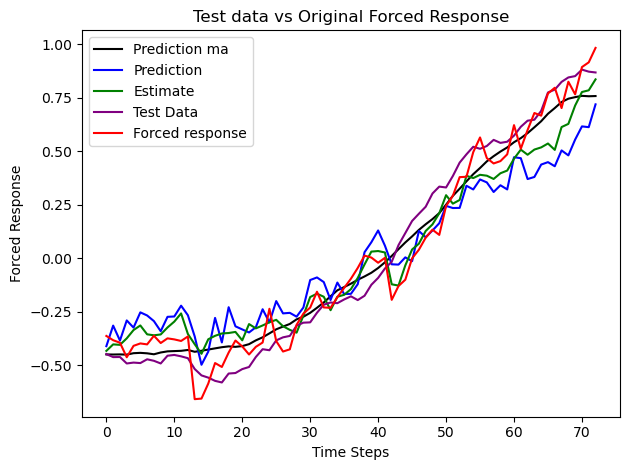

In [54]:
# plot test data vs the predicted data
import matplotlib.pyplot as plt

idx_cell = 150  # index of the grid cell to plot
idx_run = 2 # index of the run to plot
idx_lon = 30
idx_lat = 30

plt.subplot(1, 1, 1)
# for i in range(x_test_yearly.shape[0]):
#     plt.plot(x_test_yearly[i,:,idx_cell], label='Test Data', color='purple')
#     plt.plot(y_test_yearly[i,:,idx_cell], label='Original Forced Response', color='red')

# plt.plot(x_test_yearly[0,:,idx_cell], label='Test Data', color='blue')
# plt.plot(y_test_yearly[0,:,idx_cell], label='Forced response', color='red')

# plt.plot(x_test_yearly[1,:,idx_cell], label='Test Data', color='blue')
# plt.plot(y_test_yearly[1,:,idx_cell], label='Forced response', color='red')
plt.plot(y_pred_ma.reshape(y_pred.shape[0], y_pred.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,:,idx_lat,idx_lon], label='Prediction ma', color='black')
plt.plot(y_pred.reshape(y_pred.shape[0], y_pred.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,:,idx_lat,idx_lon], label='Prediction', color='blue')
plt.plot(data_estimates_yearly.reshape(30,y_pred.shape[0], y_pred.shape[1],latitude.shape[0],longitude.shape[0])[5,idx_run,:,idx_lat,idx_lon], label='Estimate', color='green')
plt.plot(x_test_ma.reshape(y_pred.shape[0], y_pred.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,:,idx_lat,idx_lon], label='Test Data', color='purple')
plt.plot(y_test_yearly.reshape(y_pred.shape[0], y_pred.shape[1],latitude.shape[0],longitude.shape[0])[idx_run,:,idx_lat,idx_lon], label='Forced response', color='red')
plt.title('Test data vs Original Forced Response')
plt.xlabel('Time Steps')
plt.ylabel('Forced Response')
plt.legend()


plt.tight_layout()
plt.show()

In [50]:
x_test_yearly.shape

torch.Size([10, 73, 10368])

In [48]:
data_estimates_yearly.shape

(30, 10, 73, 72, 144)

In [43]:
# Weighted prediction using the classifier

window_size = 3  # Define the size of the sliding window

# Create sliding windows
x_windows = np.zeros((x_stacked.shape[0]*(x_stacked.shape[1] - window_size + 1), window_size * x_stacked.shape[2]))
labels_windows = np.zeros((x_stacked.shape[0]*(x_stacked.shape[1] - window_size + 1),), dtype=np.int64)
last_idx = 0

for idx_m, m in enumerate(list(data_anomaly_yearly.keys())):
    for j in range(data_anomaly_yearly[m].shape[0]):
        for i in range(x_stacked.shape[1] - window_size + 1):
            x_windows[last_idx+i,:] = x_stacked[j, i:i + window_size, :].flatten()
            labels_windows[last_idx+i] = idx_m
        last_idx += (x_stacked.shape[1] - window_size + 1)
    
# x_windows = np.array(x_windows).reshape(-1, window_size * num_features)

In [44]:
# import sklearn
# from sklearn.linear_model import LogisticRegression


# # here continue with the training of the classifier
# num_classes = len(data_anomaly_yearly.keys())
# num_features = x_stacked.shape[2]*window_size

# # Train a logistic regression classifier
# model = LogisticRegression(max_iter=1000,penalty='l2', C=100.0, solver='saga')
# # model = sklearn.ensemble.RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# model.fit(x_windows, labels_windows)

# Generate corrupted data to make the models more robust

In [45]:
## code to generate corrupted data for each climate model
def generate_corrupted_data(data, noise_level=0.1, n_samples=10):
    """Generate corrupted data by adding Gaussian noise to the original data.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           noise_level: standard deviation of the Gaussian noise
       Return:
           corrupted_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    noise = np.random.normal(0, noise_level, (n_samples, data.shape[1],data.shape[2], data.shape[3]))

    # select a random sample from the training set using an index

    corrupted_data = data[0,:,:,:] + noise
    return corrupted_data

# Generate corrupted data with shift in data
def shift_data(data, shift=0.3):
    """Shift the data by a given number of time steps.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           shift: number of time steps to shift
       Return:
           shifted_data: numpy array of shape (runs, time steps, latitude, longitude)
    """
    # shifted_data = np.roll(data, shift=shift, axis=1)
    shifted_data = data + shift*np.random.choice([-1,0,1], data.shape)
    return shifted_data

corrupted_data_tmp = generate_corrupted_data(data_forced_response_yearly['MPI-ESM1-2-LR'], noise_level=vars['MPI-ESM1-2-LR'], n_samples=10)

print(f'Corrupted data shape: {corrupted_data_tmp.shape}')
corrupted_data_tmp = shift_data(corrupted_data_tmp)

TypeError: 'builtin_function_or_method' object is not subscriptable

In [ ]:
n_samples = 10
gamma = 1.0

# Generate corrupted data for each climate model
corrupted_data_yearly = {}
corrupted_data_yearly_forced_response = {}
for dir in list(data_anomaly_yearly.keys()):
    print(f'Generating corrupted data for {dir}')
    generated_data_yearly = generate_corrupted_data(data_forced_response_yearly[dir]**2, noise_level= gamma*vars_yearly[dir], n_samples=n_samples)
    # corrupted_data_yearly[dir] = shift_data(generated_data_yearly,shift=np.std(generated_data_yearly))
    print(f'  corrupted data shape: {generated_data_yearly.shape}')
    corrupted_data_yearly[dir] = generated_data_yearly
    corrupted_data_yearly_forced_response[dir] = np.repeat(np.expand_dims(data_forced_response_yearly[dir][0,:,:,:],axis=0),axis=0, repeats=n_samples)
    print(f'  corrupted forced response data shape: {corrupted_data_yearly_forced_response[dir].shape}')

# Merge the corrupted data into a single training set
x_train_corrupted, y_train_corrupted = merge_training_data(corrupted_data_yearly, corrupted_data_yearly_forced_response, dtype=torch.float32)

Generating corrupted data for CESM2
  corrupted data shape: (10, 221, 72, 144)
  corrupted forced response data shape: (10, 221, 72, 144)
Generating corrupted data for CanESM5
  corrupted data shape: (10, 221, 72, 144)
  corrupted forced response data shape: (10, 221, 72, 144)
Generating corrupted data for MIROC-ES2L
  corrupted data shape: (10, 221, 72, 144)
  corrupted forced response data shape: (10, 221, 72, 144)
Generating corrupted data for MIROC6
  corrupted data shape: (10, 221, 72, 144)
  corrupted forced response data shape: (10, 221, 72, 144)
Generating corrupted data for MPI-ESM1-2-LR
  corrupted data shape: (10, 221, 72, 144)
  corrupted forced response data shape: (10, 221, 72, 144)
  x_train shape: torch.Size([2210, 10368])
  x_train shape: torch.Size([4420, 10368])
  x_train shape: torch.Size([6630, 10368])
  x_train shape: torch.Size([8840, 10368])
  x_train shape: torch.Size([11050, 10368])


In [ ]:
# corrupted_data_tmp = generate_corrupted_data(data_forced_response_yearly['MPI-ESM1-2-LR'], noise_level=vars['MPI-ESM1-2-LR'], n_samples=10)

# print(f'Corrupted data shape: {corrupted_data_tmp.shape}')
# corrupted_data_tmp = shift_data(corrupted_data_tmp)

In [ ]:
# build corrupted data by taking min and max altenrnatingly of training data at each time step
def build_corrupted_data(data, n_samples=10):
    """Build corrupted data by taking min and max alternatingly of training data at each time step.
       Args:
           data: numpy array of shape (runs, time steps, latitude, longitude)
           n_samples: number of samples to generate
         Return:
              corrupted_data: numpy array of shape (n_samples, time steps, latitude, longitude) 
    """
    corrupted_data = np.zeros((n_samples, data.shape[1], data.shape[2], data.shape[3]), dtype=np.float32)
    
    for i in range(n_samples):
        if i % 2 == 0:
            corrupted_data[i,:,:,:] = np.min(data, axis=0)
        else:
            corrupted_data[i,:,:,:] = np.max(data, axis=0)
    
    return corrupted_data

NameError: name 'n_samples' is not defined

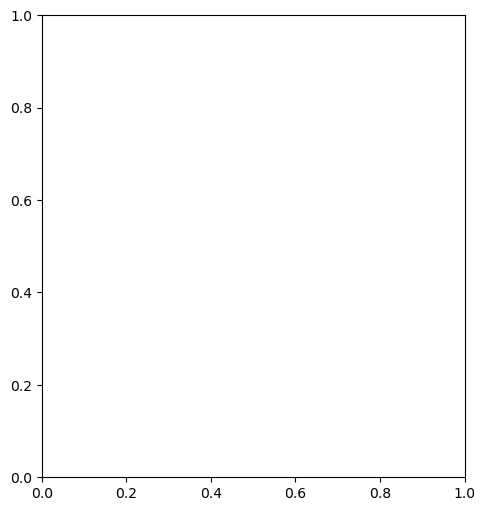

In [ ]:
import matplotlib.pyplot as plt
plt.close('all')

# plot the corrupted data vs the original data for each climate model
model_name0 = 'MPI-ESM1-2-LR'
model_name1 = 'MIROC6'
model_name2 = 'CanESM5'
idx_run = 3
idx_lat = 10
idx_lon = 10
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for i in range(n_samples):
    # plt.plot(corrupted_data_yearly[model_name0][i,:,idx_lat,idx_lon], label='Corrupted Data', color='blue')
    plt.plot(data_anomaly_yearly[model_name0][i,:,idx_lat,idx_lon], label='Original Data', color='purple')
    plt.plot(data_anomaly_yearly[model_name1][i,:,idx_lat,idx_lon], label='Corrupted Data', color='blue')

plt.plot(data_forced_response_yearly[model_name0][0,:,idx_lat,idx_lon], label='Forced response', color='red')
plt.title('Corrupted vs Original Data')
plt.xlabel('Time Steps')
plt.ylabel('Anomaly')


# model_name = 'CanESM5'

# plt.subplot(1, 2, 2)
# for i in range(n_samples):
#     plt.plot(corrupted_data_yearly[model_name][i,:,idx_lat,idx_lon], label='Corrupted Data', color='purple')
# plt.plot(data_forced_response_yearly[model_name][0,:,idx_lat,idx_lon], label='Forced Response', color='red')
# plt.title('Corrupted vs Original Forced Response')
# plt.xlabel('Time Steps')
# plt.ylabel('Forced Response')
# # plt.legend()


plt.tight_layout()
plt.show()



In [ ]:
# merge the corrupted data and the original data
x_train_combined = torch.cat([x_train_yearly, x_train_corrupted], dim=0)
y_train_combined = torch.cat([y_train_yearly, y_train_corrupted], dim=0)

In [ ]:
# penalty parameters
lambda_tmp = 5000.0

# ridge regression
w_ridge_corrupted = ridge_regression(x_train_combined, y_train_combined, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)

# low rank regression
U,S,V = torch.linalg.svd(x_train_combined@w_ridge_corrupted,full_matrices=False)

Loss function:  690789.625


In [ ]:
# define the rank
rank = 5

w_ridge_low_rank_corrupted = w_ridge_corrupted @ V[:rank,:].T@V[:rank,:]

In [ ]:
# Evaluate the model on test data
y_pred_tmp = x_test_yearly @ w_ridge_corrupted
y_pred_low_rank_tmp = x_test_yearly @ w_ridge_low_rank_corrupted


# Compute the mean squared error
rmse_tmp = torch.sqrt(torch.mean((y_pred_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
rmse_low_rank_tmp = torch.sqrt(torch.mean((y_pred_low_rank_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()

print(f'  MSE : {rmse}')
print(f'  MSE trace norm: {rmse_low_rank}')

print(f'  MSE with corrupted data: {rmse_tmp}')
print(f'  MSE trace norm with corrupted data: {rmse_low_rank_tmp}')

  MSE : [0.23408726 0.4491907  0.55577177 0.31414    0.45788807 0.24112941
 0.30960974 0.23573107 0.3058776  0.52627414]
  MSE trace norm: [0.23110066 0.445197   0.55550396 0.3100921  0.4585886  0.2381834
 0.30627918 0.2362746  0.30466568 0.52367544]
  MSE with corrupted data: [0.24438587 0.45699745 0.55625945 0.32659325 0.49876922 0.25356135
 0.31680164 0.24285094 0.3123466  0.5345612 ]
  MSE trace norm with corrupted data: [0.2385435  0.45112237 0.5548051  0.32055065 0.49672595 0.24857572
 0.3115396  0.24175061 0.30936182 0.53061986]


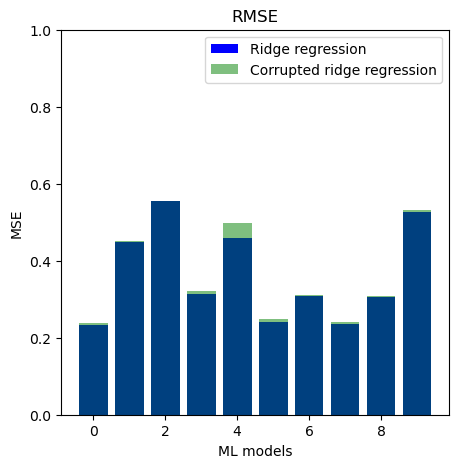

In [ ]:
plt.figure(figsize=(5, 5))
plt.bar(range(rmse.shape[0]), rmse, color='blue', label='Ridge regression')
plt.bar(range(rmse.shape[0]), rmse_low_rank_tmp, color='green', label='Corrupted ridge regression', alpha=0.5)
plt.title('RMSE')
plt.xlabel('ML models')
plt.ylabel('MSE')
plt.ylim(0, 1)
plt.legend()
plt.show()

In [ ]:
# evaluate the model on normalized test data (this is weird but let's do it)
y_pred_tmp = x_test_yearly @ w_ridge_corrupted
# Compute the mean squared error
rmse_tmp = torch.sqrt(torch.mean((y_pred_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
print(f'  MSE with normalized test data: {rmse_tmp}')
print(f'  MSE with unnormalized test data: {rmse}')

  MSE with normalized test data: [0.24438587 0.45699745 0.55625945 0.32659325 0.49876922 0.25356135
 0.31680164 0.24285094 0.3123466  0.5345612 ]
  MSE with unnormalized test data: [0.23408726 0.4491907  0.55577177 0.31414    0.45788807 0.24112941
 0.30960974 0.23573107 0.3058776  0.52627414]


In [ ]:
lambda_tmp = 5000.0
w_ridge_corrupted= {}
w_ridge_low_rank_corrupted = {}

rmse_corrupted_per_model = {}
rmse_low_rank_corrupted_per_model = {}

# training for corrupted data of each climate model
for dir in list(corrupted_data_yearly.keys()):
    print(f'Computing ridge regression for {dir}')

    # merge the corrupted data  and the original data for this specific model 
    x_train_yearly_tmp = torch.from_numpy(data_anomaly_yearly[dir]).to(torch.float32).reshape(data_anomaly_yearly[dir].shape[0]*data_anomaly_yearly[dir].shape[1],data_anomaly_yearly[dir].shape[2]*data_anomaly_yearly[dir].shape[3])    
    y_train_yearly_tmp = torch.from_numpy(data_forced_response_yearly[dir]).to(torch.float32).reshape(data_forced_response_yearly[dir].shape[0]*data_forced_response_yearly[dir].shape[1],data_forced_response_yearly[dir].shape[2]*data_forced_response_yearly[dir].shape[3])

    x_train_tmp = torch.from_numpy(corrupted_data_yearly[dir]).to(torch.float32).reshape(corrupted_data_yearly[dir].shape[0]*corrupted_data_yearly[dir].shape[1],corrupted_data_yearly[dir].shape[2]*corrupted_data_yearly[dir].shape[3])
    y_train_tmp = torch.from_numpy(corrupted_data_yearly_forced_response[dir]).to(torch.float32).reshape(corrupted_data_yearly_forced_response[dir].shape[0]*corrupted_data_yearly_forced_response[dir].shape[1],corrupted_data_yearly_forced_response[dir].shape[2]*corrupted_data_yearly_forced_response[dir].shape[3])


    # merge the training data 
    x_train_combined = torch.cat([x_train_yearly_tmp, x_train_tmp], dim=0)
    y_train_combined = torch.cat([y_train_yearly_tmp, y_train_tmp], dim=0)
    print(f'  x_train_combined shape: {x_train_combined.shape}')
    print(f'  y_train_combined shape: {y_train_combined.shape}')

    w_ridge_corrupted[dir] = ridge_regression(x_train_combined, y_train_combined, lambda_= lambda_tmp, verbose=True, dtype=torch.float32)
    
    # low rank regression
    U,S,V = torch.linalg.svd(x_train_combined@w_ridge_corrupted[dir],full_matrices=False)

    # # define the rank
    rank = 5

    w_ridge_low_rank_corrupted[dir] = w_ridge_corrupted[dir] @ V[:rank,:].T@V[:rank,:]

    # Evaluate the model on test data
    y_pred_tmp = x_test_yearly @ w_ridge_per_model[dir]
    y_pred_low_rank_tmp= x_test_yearly @ w_ridge_low_rank_per_model[dir]

    # Compute the mean squared error
    rmse_corrupted_per_model[dir] = torch.sqrt(torch.mean((y_pred_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()
    rmse_low_rank_corrupted_per_model[dir] = torch.sqrt(torch.mean((y_pred_low_rank_tmp - y_test_yearly) ** 2,axis=(1,2))).detach().numpy()


    print(f'  MSE : {rmse_per_model[dir]}')
    print(f'  MSE trace norm: {rmse_low_rank_per_model[dir]}')

Computing ridge regression for CESM2
  x_train_combined shape: torch.Size([13260, 10368])
  y_train_combined shape: torch.Size([13260, 10368])
Loss function:  2058251.0


  MSE : [0.2169267  0.29392555 0.68550867 0.30151156 0.26509786 0.23596564
 0.33374625 0.2291324  0.24291089 0.42716157]
  MSE trace norm: [0.21688904 0.29422173 0.68569887 0.30193377 0.26811126 0.23532832
 0.33364794 0.22926287 0.24240029 0.42679167]
Computing ridge regression for CanESM5
  x_train_combined shape: torch.Size([7735, 10368])
  y_train_combined shape: torch.Size([7735, 10368])
Loss function:  2579844.5
  MSE : [0.23224266 0.45231438 0.55990654 0.3016071  0.535329   0.24826068
 0.31727988 0.26938167 0.30519813 0.45985106]
  MSE trace norm: [0.23085418 0.45125166 0.5588977  0.30023223 0.53605413 0.24678877
 0.3165198  0.2690003  0.3038592  0.45885006]
Computing ridge regression for MIROC-ES2L
  x_train_combined shape: torch.Size([8840, 10368])
  y_train_combined shape: torch.Size([8840, 10368])
Loss function:  1418931.25
  MSE : [0.22372659 0.3482394  0.59716135 0.2759286  0.3854396  0.25224632
 0.29183197 0.23743449 0.30813706 0.4659395 ]
  MSE trace norm: [0.2240215  0.3

In [ ]:
weights_corrupted = compute_weights(w_ridge_corrupted,x_reshaped,y_reshaped)
weights_low_rank_corrupted = compute_weights(w_ridge_low_rank_corrupted,x_reshaped,y_reshaped)

y_pred_corrupted = weighted_prediction(weights_corrupted, w_ridge_corrupted, x_test_yearly)
y_pred_low_rank_corrupted = weighted_prediction(weights_low_rank_corrupted, w_ridge_low_rank_corrupted, x_test_yearly)

# Compute the mean squared error
rmse_weighted_corrupted = torch.sqrt(torch.mean((y_pred_corrupted - y_test_yearly) ** 2, axis=(1, 2))).detach().numpy()
rmse_weighted_low_rank_corrupted = torch.sqrt(torch.mean((y_pred_low_rank_corrupted - y_test_yearly) ** 2, axis=(1, 2))).detach().numpy()


print(f'  MSE: {rmse}')
print(f'  MSE trace norm: {rmse_low_rank}')
print(f'  MSE weighted prediction: {rmse_weighted}')
print(f'  MSE weighted prediction trace norm: {rmse_weighted_low_rank}')
print(f'  MSE weighted prediction with corrupted data: {rmse_weighted_corrupted}')
print(f'  MSE weighted prediction low-rank with corrupted data: {rmse_weighted_low_rank_corrupted}')

  distances shape: torch.Size([50])
  distances shape: torch.Size([25])
  distances shape: torch.Size([30])
  distances shape: torch.Size([50])
  distances shape: torch.Size([30])
  distances shape: torch.Size([50])
  distances shape: torch.Size([25])
  distances shape: torch.Size([30])
  distances shape: torch.Size([50])
  distances shape: torch.Size([30])
  MSE: [0.23408726 0.4491907  0.55577177 0.31414    0.45788807 0.24112941
 0.30960974 0.23573107 0.3058776  0.52627414]
  MSE trace norm: [0.23110066 0.445197   0.55550396 0.3100921  0.4585886  0.2381834
 0.30627918 0.2362746  0.30466568 0.52367544]
  MSE weighted prediction: [0.18047471 0.29754883 0.61713684 0.25677902 0.28952312 0.22255068
 0.284985   0.1938374  0.24915868 0.42321682]
  MSE weighted prediction trace norm: [0.18065926 0.29684982 0.6172423  0.25717556 0.2906155  0.22340922
 0.28513235 0.19318333 0.24921165 0.4228741 ]
  MSE weighted prediction with corrupted data: [0.19669248 0.31332213 0.607496   0.25856912 0.30075